# [Práctica 4] Fundamentos de Ciencia de Datos
Alejandra Fernández (afernandezm@inf.udec.cl)

# Contenidos
-  **Regresión Lineal**
    - Definir un modelo de regresion lineal
    - Ver los coeficientes y crear la función a mano
- **Métricas de evaluación**
- **Ejemplo**
- **Regresión Polinomial**
    - Definir un modelo de regresion polinomial
    - Ejercicio
- **Validación Cruzada**
  - Sesgo y varianza
  - Como realizar validación cruzada
    - Si ya tengo conjunto de validacion
    - Si quiero utilizar el método de Kfold
- **Ejercicio**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn # scikit-learn, nueva libreria

#Regresión Lineal

Dado un conjunto de datos $(X,Y)$, queremos determinar una función que permita predecir el valor de salida de nuevos datos. Cuando el valor que debe ser predicho es un número continuo, el problema es una regresión.

Fórmula Regresión Lineal:

$Y = \sum \theta_i X_i + \epsilon  $

El número de parámetros depende de nuestro conjunto de datos.

Si tenemos $k$ variables explícitas, necesitamos $k + 1$ parámetros.

## Definir una regresión lineal

Si $k = 1$ :

$Y = \theta_0 + \theta_1X + \epsilon  $

La ecuación anterior se parece a la ecuación de la recta:

$ y = mx + b$

Donde $m$ es la pendiente y $b$ es el punto de intersección en la ordenada.

Primero, generamos un dataset con muestras aleatorias usando la librería sklearn

In [ ]:
from sklearn.datasets import make_regression

n_samples = 1000
X, y = sklearn.datasets.make_regression(n_samples=n_samples,
                                        n_features=1,
                                        n_informative=1,
                                        noise=10,
                                        random_state=0)

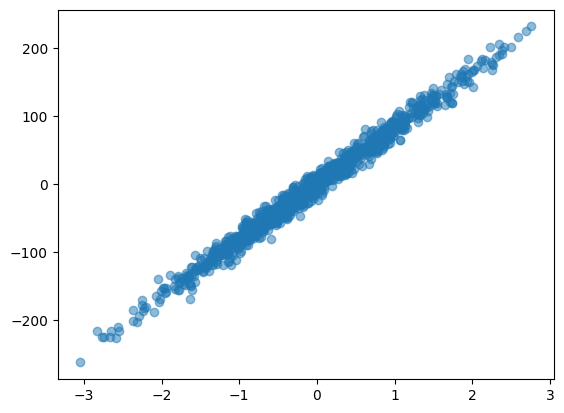

In [ ]:
plt.scatter(X,y, alpha=0.5)
plt.show()

Vamos a ocupar la clase LinearRegression de la libreria scikit learn (sklearn) para ajustar un modelo de regresión a nuestros datos.

Algo importante es el formato de los datos cuando utilizamos LinearRegression.

Necesitamos pasar la matriz $X$ con $m$ filas y $n$ columnas, donde :
- cada fila es un dato ($m$ = número de datos)
- cada columna es un atributo ($n = k$)

El arreglo $Y$ debe tener $m$ filas y 1 columna.

In [ ]:
print('Shape X: ', X.shape)
print('Shape y: ', y.shape)

Shape X:  (1000, 1)
Shape y:  (1000,)


In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression() #Creamos un modelo
lin_reg.fit(X, y)  #Entrenamos el modelo

LinearRegression()

Ahora que ya tenemos una regresión lineal entrenada con los datos... ¡hagamos predicciones!
Creemos datos aleatorios a partir del valor mínimo y máximo de X y luego predigamos de esa entrada los valores de y.

In [ ]:
test_X = np.arange(X.min(),X.max())
print(test_X.shape)

(6,)


Para hacer predicciones es importante recordar que el arreglo $Y$ debe tener una sola dimensión (para este caso), por lo cual hay que cambiar sus dimensiones

In [ ]:
test_X = test_X.reshape(-1,1)
test_X.shape

(6, 1)

Tenemos 6 valores de X.
Se los pasaremos al modelo para obtener 6 valores de y

In [ ]:
y_pred = lin_reg.predict(test_X)
y_pred.shape

(6,)

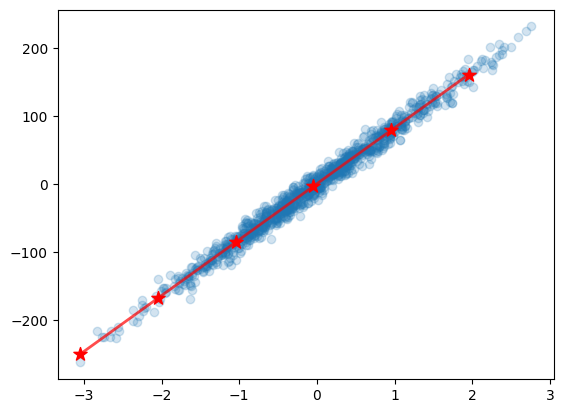

In [ ]:
plt.figure()
plt.scatter(X,y, alpha=0.2)
plt.plot(test_X, y_pred, color='red', linewidth=2, alpha=0.7)
plt.scatter(test_X, y_pred, color='r', s=100, marker='*')
plt.show()

## Veamos los coeficientes y construyamos la función a mano

Para ver los parámetros

In [ ]:
print("Pendiente:    ", lin_reg.coef_)
print("b:", lin_reg.intercept_)

Pendiente:     [82.1313384]
b: 0.2587758377631486


Entonces:

$Y = \theta_0 + \theta_1X + \epsilon  $

$\theta_0 = b = 0.2587758377631486 $

$\theta_1 = m = 82.1313384 $


In [ ]:
def funcion(X, m , b):
  y = X * m + b
  return y

In [ ]:
y_pred = funcion(test_X, lin_reg.coef_, lin_reg.intercept_)
print(y_pred)

[[-249.92503021]
 [-167.79369181]
 [ -85.66235341]
 [  -3.53101501]
 [  78.60032339]
 [ 160.73166179]]


In [ ]:
test_X

array([[-3.04614305],
       [-2.04614305],
       [-1.04614305],
       [-0.04614305],
       [ 0.95385695],
       [ 1.95385695]])

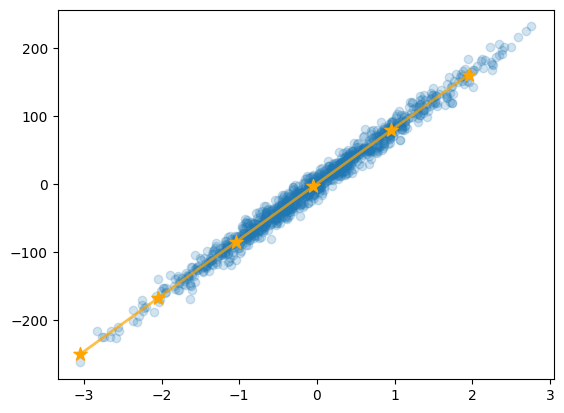

In [ ]:
plt.scatter(X,y, alpha=0.2)
plt.plot(test_X, y_pred, color='orange', linewidth=2, alpha=0.7)
plt.scatter(test_X, y_pred, color='orange', s=100, marker='*')
plt.show()

# Metricas de evaluación

Si queremos evaluar un modelo, debemos comparar el valor de la predicción con el valor esperado. Es importante utilizar un conjunto de datos aparte de el utilizado para entrenar para realizar la evaluación final del modelo.

En la [documentación de scikit learn](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics) se pueden ver todas las métricas disponibles. Aqui utilizaremos el **r2** y el **error cuadratico medio**

R2 SCORE

<img src = "https://wikimedia.org/api/rest_v1/media/math/render/svg/44a8b57e2a4335f02faa2bd5003d94979af4f408">
<br>
<img src = "https://wikimedia.org/api/rest_v1/media/math/render/svg/2669c9340581d55b274d3b8ea67a7deb2225510b" >
<br>
<img src = "https://wikimedia.org/api/rest_v1/media/math/render/svg/3a1f55d7e84c24299917fb3fec4d0439b81e728d" >
<br>
<img src = "https://wikimedia.org/api/rest_v1/media/math/render/svg/c7e3ab84636f38c257641f85f009bcb422c73151">

*Fuente: Wikipedia*

MSE

<img src = "https://wikimedia.org/api/rest_v1/media/math/render/svg/e258221518869aa1c6561bb75b99476c4734108e" >

*Fuente: Wikipedia*

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# para evaluar debemos conocer los valores reales
y_pred = lin_reg.predict(X)

print('Error cuadrático medio: %.2f' % mean_squared_error(y, y_pred))
print('Estadístico R_2: %.2f' % r2_score(y, y_pred))

Error cuadrático medio: 98.44
Estadístico R_2: 0.99


# Ejemplo

## Dataset: California Housing (sklearn)

El dataset **California Housing** es una base de datos real recopilada a partir del censo de California de 1990. Contiene información de distintos distritos del estado, con variables demográficas, geográficas y económicas.

El objetivo común al usar este dataset es **predecir el valor medio de las viviendas** (`MedHouseVal`) en cada distrito, a partir de variables como el ingreso medio, la antigüedad de las viviendas, el número promedio de habitaciones, la latitud y longitud, entre otras.

#### Columnas
  - `MedInc`: ingreso medio de los hogares en decenas de miles de dólares
  - `HouseAge`: media de años de antigüedad de las viviendas
  - `AveRooms`: número promedio de habitaciones por hogar
  - `AveBedrms`: promedio de dormitorios por hogar
  - `Population`: población total del distrito
  - `AveOccup`: número promedio de habitantes por hogar
  - `Latitude`, `Longitude`: ubicación geográfica
  - `MedHouseVal`: valor medio de las viviendas del distrito (en cientos de miles de USD)


In [ ]:
from sklearn.datasets import fetch_california_housing #cargar el dataset
from sklearn.model_selection import train_test_split #dividir los datos

# Cargar dataset
data = fetch_california_housing(as_frame=True)
df = data.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
correlacion = df.corr(numeric_only=True)
correlacion

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: >

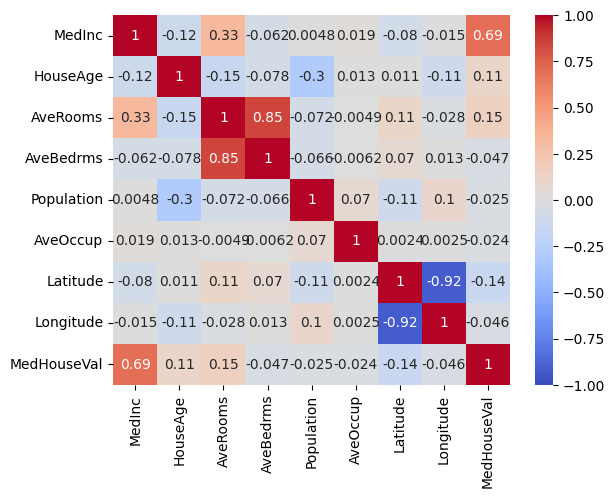

In [ ]:
import seaborn as sns
#plt.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)
sns.heatmap(correlacion, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

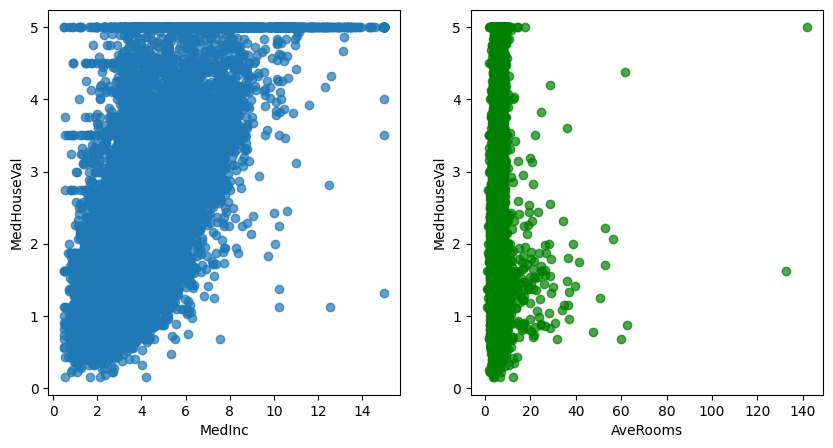

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(df.MedInc,df.MedHouseVal, alpha=0.7)
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.subplot(1,2,2)
plt.scatter(df.AveRooms,df.MedHouseVal, color="green", alpha=0.7)
plt.xlabel('AveRooms')
plt.ylabel('MedHouseVal')
plt.show()

In [ ]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [ ]:
#Vamos a usar todas las columnas
X = df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude']]
y = df["MedHouseVal"]

In [ ]:
# train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# train-val
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 13209, Val: 3303, Test: 4128


In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lin_reg.predict(X_test)

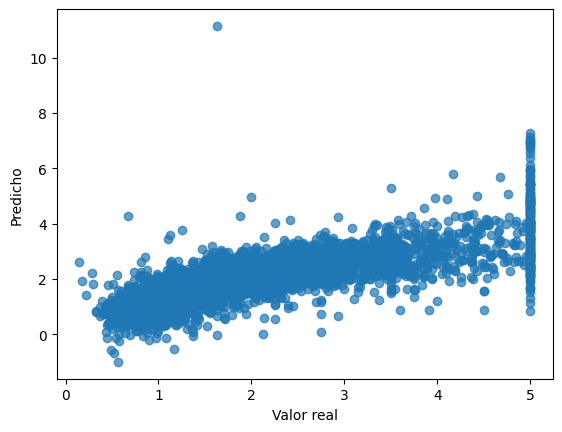

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Valor real')
plt.ylabel('Predicho')
plt.show()

In [ ]:
lin_reg.intercept_

np.float64(-36.58848844681285)

In [ ]:
print(f"R²: {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")

R²: 0.577
MSE: 0.554


In [ ]:
lin_reg.coef_

array([ 4.51677294e-01,  9.61175544e-03, -1.25857507e-01,  7.81542768e-01,
       -7.34262763e-06, -3.97086853e-03, -4.16854763e-01, -4.29343454e-01])

In [ ]:
# Vamos a analizar el modelo
coef = pd.Series(lin_reg.coef_, index=X_train.columns)
abs(coef).sort_values(ascending=False)

,0
AveBedrms,0.781543
MedInc,0.451677
Longitude,0.429343
Latitude,0.416855
AveRooms,0.125858
HouseAge,0.009612
AveOccup,0.003971
Population,0.000007


In [ ]:
X_train.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [ ]:
#Vamos a intentar nuestro mismo código de antes pero ahora con menos features
#Vamos a entrenar solo con las columnas 3,0,6,7
cols = [0,2,3,6,7]
X_train_s = X_train.iloc[:, cols]
y_train_s = y_train
X_test_s = X_test.iloc[:, cols]
y_test_s = y_test

In [ ]:
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_train_s, y_train_s)

LinearRegression()

In [ ]:
y_pred_2 = lin_reg_2.predict(X_test_s)

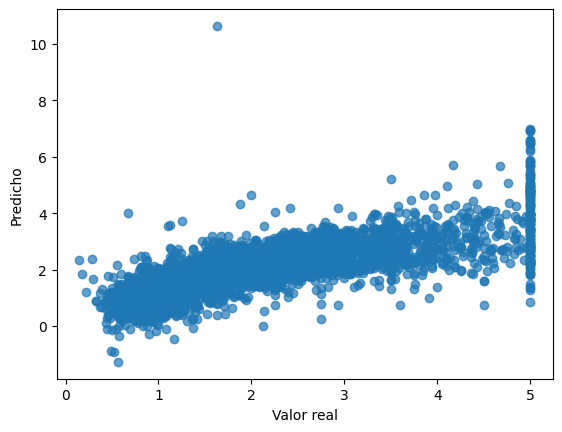

In [ ]:
plt.scatter(y_test_s, y_pred_2, alpha=0.7)
plt.xlabel('Valor real')
plt.ylabel('Predicho')
plt.show()

In [ ]:
print(f"R²: {r2_score(y_test_s, y_pred_2):.3f}")
print(f"MSE: {mean_squared_error(y_test_s, y_pred_2):.3f}")

R²: 0.569
MSE: 0.565


#Regresión Polinomial

**Regresión lineal con transformación polinomial**

La regresión lineal solo puede modelar relaciones lineales entre las variables de entrada y la salida. Si la relación real es no lineal, podemos transformar las variables para que una regresión lineal pueda modelarla.

Entonces de la expresión:

$Y = \sum \theta_i X_i + \epsilon  $

Pasamos a :

$Y = \sum \theta_i g_i(X_i) + \epsilon  $

Donde $g_i(\boldsymbol{x})$ no es lineal con respecto a $\boldsymbol{x}$.

En el caso de la regresión polinomial, la expresión queda como :

$y_i =\theta_0 + \theta_1x_i + \theta_2x_i^2 + \cdots + \theta_kx_i^k +\epsilon_i$

Antes teniamos el parámetro $i$ que definia cuantos parametros tenia nuestra regresión (lo cual dependia directamente de nuestros datos, ya que era el número de columnas que usariamos para predecir), pero ahora existe el parámetro $k$, cuyo valor no depende de los datos, por lo que se transforma en un **hiperparametro**.

In [ ]:
x = np.array([1, 3, 6, 10, 20, 22, 26, 28])
y = np.array([5, 7, 8, 6.5, -1, 1, 8, 7])
x_extra = np.array([12,13, 16, 22, 23, 25])
y_extra = np.array([5, 3, 0, 2, 4, 6])

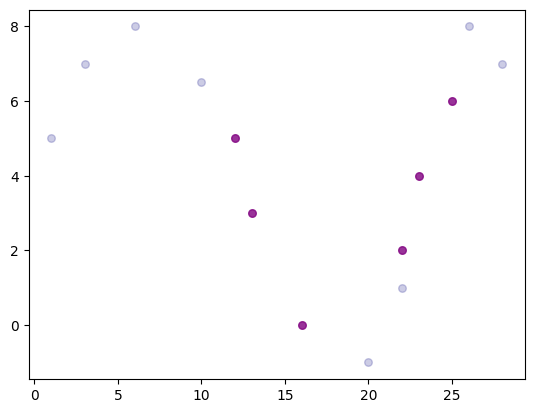

In [ ]:
plt.scatter(x, y, color='navy', s=30, marker='o',alpha=0.2)
plt.scatter(x_extra, y_extra, color='purple', s=30, marker='o',alpha=0.8)
plt.show()

In [ ]:
modelo = LinearRegression()
modelo.fit(x.reshape(-1,1), y.reshape(-1,1)) #Vamos a intentar utilizar una regresion lineal

LinearRegression()

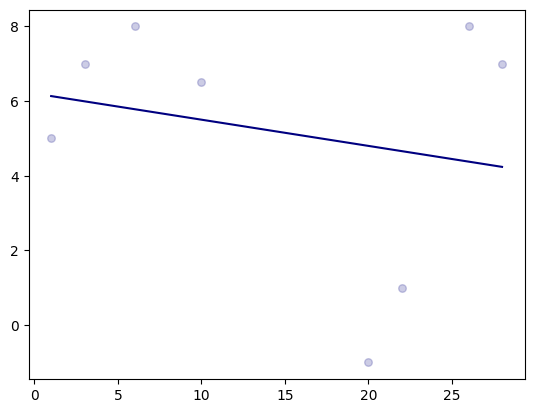

In [ ]:
y_pred = modelo.predict(x.reshape(-1,1))
plt.scatter(x, y, color='navy', s=30, marker='o',alpha=0.2)
plt.plot(x, y_pred, color='navy')
plt.show()

Vemos que una regresión lineal no se modela bien el comportamiento de los datos, por lo que utilizaremos regresión polinomial. Para esto ocuparemos **PolynomialFeatures** de scikit-learn.

## Definir una regresión polinomial

No existe un modelo construido directamente tal como LinearRegresion() para la regresión polinomial. Lo que se hace es crear un modelo utilizando como base una regresion lineal y utilizando la función **PolynomialFeatures** que devuelve las potencias de un valor hasta el grado que se indique.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
transformer = PolynomialFeatures(degree=3)
transformer.fit(x.reshape(-1,1))
x_ = transformer.transform(x.reshape(-1,1))
print(x)
print(x_)

[ 1  3  6 10 20 22 26 28]
[[1.0000e+00 1.0000e+00 1.0000e+00 1.0000e+00]
 [1.0000e+00 3.0000e+00 9.0000e+00 2.7000e+01]
 [1.0000e+00 6.0000e+00 3.6000e+01 2.1600e+02]
 [1.0000e+00 1.0000e+01 1.0000e+02 1.0000e+03]
 [1.0000e+00 2.0000e+01 4.0000e+02 8.0000e+03]
 [1.0000e+00 2.2000e+01 4.8400e+02 1.0648e+04]
 [1.0000e+00 2.6000e+01 6.7600e+02 1.7576e+04]
 [1.0000e+00 2.8000e+01 7.8400e+02 2.1952e+04]]


In [ ]:
from sklearn.pipeline import make_pipeline
#definimos un metodo para la regresion polinomial
def PolynomialRegression(degree=2, **kwargs): #Por defecto tendrá grado 0
    return make_pipeline(sklearn.preprocessing.PolynomialFeatures(degree),
                         LinearRegression(**kwargs))

Vamos a crear regresiones polinomiales de los grados 2 al 7 y una regresión lineal (grado = 1) para los puntos mostrados anteriormente.

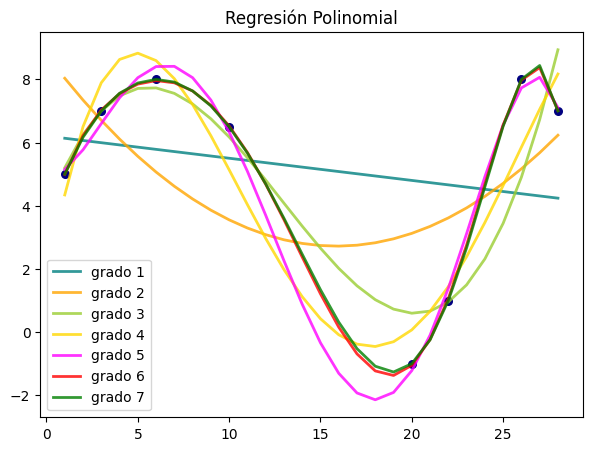

In [ ]:
plt.figure(figsize=(7,5))
colors = ['teal', 'orange', 'yellowgreen', 'gold','magenta','red','green']
plt.scatter(x, y, color='navy', s=30, marker='o')
X_plot = np.arange(x.min(),x.max()+1) #Creamos puntos para usarlos de test

aux_params = []
aux_bias = []
plt.title("Regresión Polinomial")
for count, degree in enumerate([1, 2, 3, 4, 5, 6, 7]):
    model = PolynomialRegression(degree) #Creamos un modelo con la función que definimos
    model.fit(x.reshape(-1,1), y.reshape(-1,1)) #Le pasamos los puntos para entrenar
    y_plot = model.predict(X_plot.reshape(-1,1)) #Predecimos
    plt.plot(X_plot, y_plot, color=colors[count], linewidth=2,
             label="grado %d" % degree, alpha=0.8) #Dibujamos X y la predicción de X
plt.legend()
plt.show()

Podemos observar que mientras mas alto el grado del polinomio, mas flexible es el modelo y, por ende, mejora el ajuste.Pero al aumentar arbitrariamente el grado del polinomio, podemos sobreajustarnos a los datos.

In [ ]:
#El ultimo modelo creado es la regresión de grado 7
#Para acceder a los coeficientes (si es que quisieramos construir la función):
print(model.named_steps)
print("Grado", model.named_steps["polynomialfeatures"].degree)
print("Coeficientes:", model.named_steps['linearregression'].coef_)
print("Bias: ", model.named_steps['linearregression'].intercept_)

{'polynomialfeatures': PolynomialFeatures(degree=7), 'linearregression': LinearRegression()}
Grado 7
Coeficientes: [[ 0.00000000e+00  1.83200187e+00 -2.65549636e-01  2.14485418e-02
  -1.26593765e-03  1.13949763e-05  1.85360651e-06 -4.60676457e-08]]
Bias:  [3.413352]


## Ejercicio: Escribir la función del polinomio de grado 7


In [ ]:
#Como seria la función?

def funcion_poly(X, grado, coeficientes, bias):
  prediccion = 0
  for k in range(grado):
    prediccion += X**(k+1) * coeficientes[0][k+1] #Vamos calculando x^k * parametro_k
  prediccion += bias #Agregamos parametro_0
  return prediccion

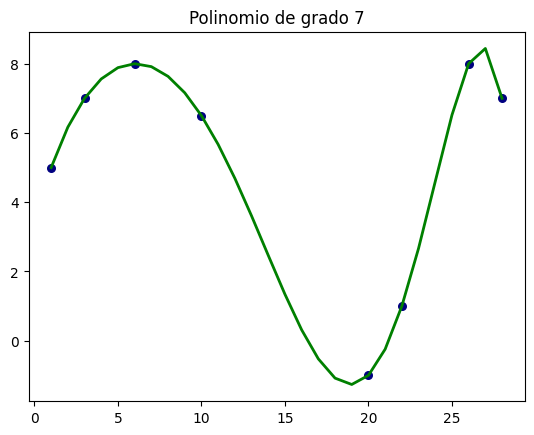

In [ ]:
plt.title("Polinomio de grado 7")
plt.scatter(x, y, color='navy', s=30, marker='o')
coef = model.named_steps['linearregression'].coef_
bias = model.named_steps['linearregression'].intercept_
grado = model.named_steps["polynomialfeatures"].degree
plt.plot(X_plot, funcion_poly(X_plot,grado,coef, bias), color="green", linewidth=2)
plt.show()

# Validación Cruzada

## Sesgo y Varianza

Mientras escogemos el grado del polinomio nos vamos a encontrar con los problemas de *underfitting* y *overfitting*.

Grafiquemos polinomios de grados $4,7,10,13$ y calculemos su $r2$ y $mse$.

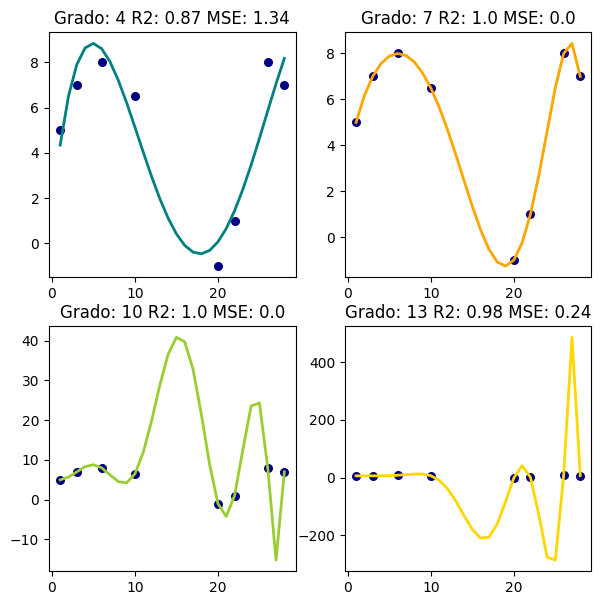

In [ ]:
plt.figure(figsize=(7,7))

X_plot = np.arange(x.min(),x.max()+1)
X_plot = X_plot[:, np.newaxis]
for count, degree in enumerate([4, 7, 10, 13]):
  plt.subplot(2, 2, count+1)
  #plt.scatter(x_extra, y_extra, color='purple', s=30, marker='o',alpha=0.5)
  plt.scatter(x, y, color='navy', s=30, marker='o')
  model = PolynomialRegression(degree)
  model.fit(x.reshape(-1,1), y.reshape(-1,1))
  y_plot = model.predict(X_plot.reshape(-1,1)) #Para dibujar pasamos el X_plot
  y_pred = model.predict(x.reshape(-1,1)) #Para predecir pasamos la coordenada x de los puntos de entrenamiento
  plt.plot(X_plot, y_plot, color=colors[count], linewidth=2)
  plt.title("Grado: " + str(degree) + " R2: "+ str(np.round( r2_score(y, y_pred),2)) + " MSE: " + str(np.round(mean_squared_error(y, y_pred),2)))
plt.show()

Entonces: Como escogemos el grado del polinomio? Necesitamos un conjunto de validacion

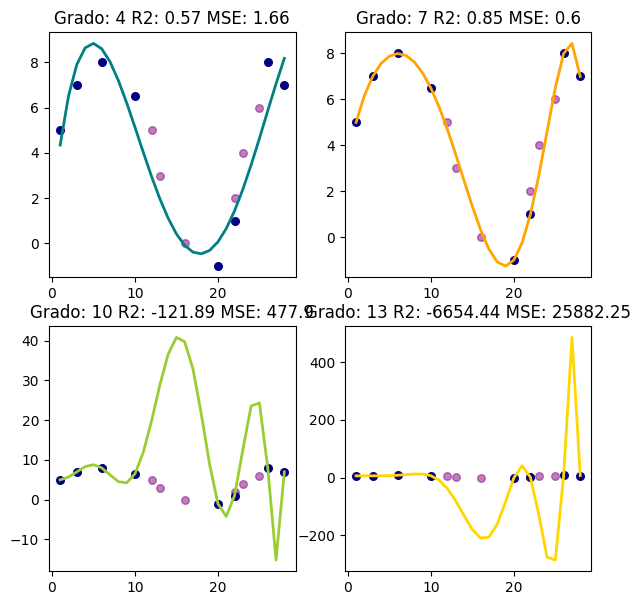

In [ ]:
plt.figure(figsize=(7,7))

X_plot = np.arange(x.min(),x.max()+1)
X_plot = X_plot[:, np.newaxis]

for count, degree in enumerate([4, 7, 10, 13]):
  plt.subplot(2, 2, count+1)
  plt.scatter(x_extra, y_extra, color='purple', s=30, marker='o',alpha=0.5, label = "validacion")
  plt.scatter(x, y, color='navy', s=30, marker='o', label= "entrenamiento")
  model = PolynomialRegression(degree)
  model.fit(x.reshape(-1,1), y.reshape(-1,1))
  y_plot = model.predict(X_plot.reshape(-1,1)) #Para dibujar pasamos el X_plot
  y_pred = model.predict(x_extra.reshape(-1,1)) #Para predecir pasamos los datos de validacion
  plt.plot(X_plot, y_plot, color=colors[count], linewidth=2)
  plt.title("Grado: " + str(degree) + " R2: "+ str(np.round( r2_score(y_extra, y_pred),2)) + " MSE: " + str(np.round(mean_squared_error(y_extra, y_pred),2)))

plt.show()

## Como realizar validación cruzada

 <h3> Conjunto de datos</h3>

Para realizar validacion cruzada, debemos dividir nuestro conjunto de datos

*¿Por qué? Yo no puedo evaluar/probar mi modelo con el mismo conjunto de datos que uso para el entrenamiento*

**Conjunto de entrenamiento:** Usar para entrenar el modelo.

**Conjunto de validación:** Es un conjunto de datos distinto al conjunto de entrenamiento. Podemos sacar un porcentaje de nuestro conjunto de entrenamiento para usarlo como conjunto de validación. El conjunto de validación indica el rendimiento del modelo en el entrenamiento. Con él se puede ajustar los hiperparámetros de los modelos.

**Conjunto de prueba**: Conjunto de datos distinto al de entrenamiento y al de validación, sobre el cual evaluaremos el modelo.

<h3>¿Y si tengo pocos datos de entrenamiento?</h3>

<h3>KFold</h3>

<img src= "https://scikit-learn.org/stable/_images/grid_search_cross_validation.png" width="600" height="400">

Para realizar validación cruzada necesito definir :
- Que hiperparámetros voy a ajustar
- Que valores pueden tomar los hiperparámetros

In [ ]:
#En este caso para poder ocupar validación cruzada con regresión polinomial tenemos que definirla como un modelo
from sklearn.base import BaseEstimator
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


class PolynomialRegression(BaseEstimator): #Necesario crear una clase utilizando de base el BaseEstimator para ocupar cv
  def __init__(self, grado = None):
    self.grado = grado

  def fit(self, X, Y, grado = None):
    self.model = make_pipeline(sklearn.preprocessing.PolynomialFeatures(self.grado),
                         LinearRegression())
    self.model.fit(X,Y)

  def predict(self, X):
    return self.model.predict(X)

  @property
  def coef_(self):
    return self.model.named_steps['linearregression'].coef_

  @property
  def intercept_(self):
    return self.model.named_steps['linearregression'].intercept_


In [ ]:
# ¿Que parametros vamos a ajustar? El grado del polinomio solamente
# ¿Que valores vamos a probar para el parámetro grado? Para este ejemplo: 4, 7, 10 y 13

#diccionario de parámetros y sus valores
parametros = {
    "grado": [4,7,10,13]
}

### Si ya tengo datos de validación

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import PredefinedSplit #Para indicar conjunto de validacion
#Creamos nuestro modelo
modelo = PolynomialRegression()
#Creamos nuestra instancia de la validacion cruzada (es como un modelo)

#Si yo ya tengo un conjunto de validación aparte y no quiero utilizar el metodo de K-fold
datos_x = np.concatenate((x,x_extra))
datos_y = np.concatenate((y,y_extra))
split_index = [-1]*len(x) + [0]*len(x_extra)
pds = PredefinedSplit(test_fold = split_index)

cv_model = GridSearchCV(modelo,
                        parametros,
                        cv=pds,
                        scoring='neg_mean_squared_error',
                        verbose=3) #Le pasamos el modelo, los parametros, el indicador para ver cuando los datos son train o val y la métrica


cv_model.fit(datos_x.reshape(-1,1), datos_y.reshape(-1,1))

Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV 1/1] END ..........................grado=4;, score=-1.660 total time=   0.0s
[CV 1/1] END ..........................grado=7;, score=-0.601 total time=   0.0s
[CV 1/1] END .......................grado=10;, score=-477.897 total time=   0.0s
[CV 1/1] END .....................grado=13;, score=-25882.250 total time=   0.0s


GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,  0])),
             estimator=PolynomialRegression(),
             param_grid={'grado': [4, 7, 10, 13]},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
#Le pido que me diga la combinación de parámetros que mejor se ajusta a los datos
cv_model.best_params_

{'grado': 7}

In [ ]:
#Para guardar el mejor modelo
mejor_modelo = cv_model.best_estimator_
mejor_modelo

PolynomialRegression(grado=7)

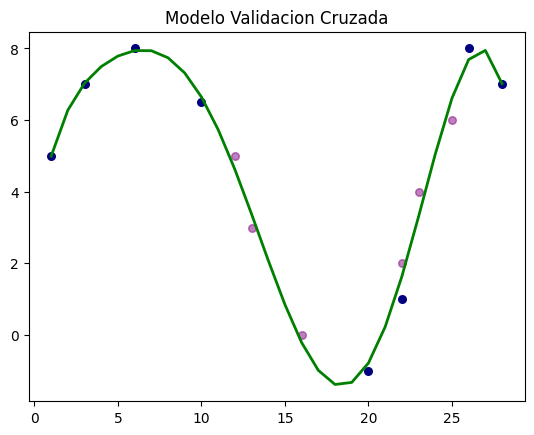

In [ ]:
X_plot = np.arange(x.min(),x.max()+1)
prediccion = mejor_modelo.predict(X_plot.reshape(-1,1))

plt.title("Modelo Validacion Cruzada")
plt.scatter(x_extra, y_extra, color='purple', s=30, marker='o',alpha=0.5)
plt.scatter(x, y, color='navy', s=30, marker='o')
plt.plot(X_plot, prediccion, color="green", linewidth=2)
plt.show()

### Si quiero utilizar el método de Kfold

In [ ]:
from sklearn.model_selection import GridSearchCV
#Creamos nuestro modelo
modelo = PolynomialRegression()
#Creamos nuestra instancia de la validacion cruzada (es como un modelo)

datos_x = np.concatenate((x,x_extra))
datos_y = np.concatenate((y,y_extra))
numero_folds = 3

cv_model = GridSearchCV(modelo,
                        parametros,
                        cv=numero_folds, #Aqui se indica el numero de folds
                        scoring='neg_mean_squared_error',
                        verbose=3) #Le pasamos el modelo, los parametros, numero de folds y la métrica


cv_model.fit(datos_x.reshape(-1,1), datos_y.reshape(-1,1))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV 1/3] END .......................grado=4;, score=-2756.670 total time=   0.0s
[CV 2/3] END .........................grado=4;, score=-15.403 total time=   0.0s
[CV 3/3] END ..........................grado=4;, score=-1.875 total time=   0.0s
[CV 1/3] END ..................grado=7;, score=-442069989.903 total time=   0.0s
[CV 2/3] END ........................grado=7;, score=-146.113 total time=   0.0s
[CV 3/3] END ..........................grado=7;, score=-0.625 total time=   0.0s
[CV 1/3] END .....................grado=10;, score=-39935.217 total time=   0.0s
[CV 2/3] END .......................grado=10;, score=-973.630 total time=   0.0s
[CV 3/3] END .........................grado=10;, score=-3.954 total time=   0.0s
[CV 1/3] END .......................grado=13;, score=-209.990 total time=   0.0s
[CV 2/3] END ...................grado=13;, score=-4177811.070 total time=   0.0s
[CV 3/3] END .......................grado=13;, sc

GridSearchCV(cv=3, estimator=PolynomialRegression(),
             param_grid={'grado': [4, 7, 10, 13]},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
#Le pido que me diga la combinación de parámetros que mejor se ajusta a los datos
print(cv_model.best_params_)

{'grado': 4}


In [ ]:
#Para guardar el mejor modelo
mejor_modelo = cv_model.best_estimator_
mejor_modelo

PolynomialRegression(grado=4)

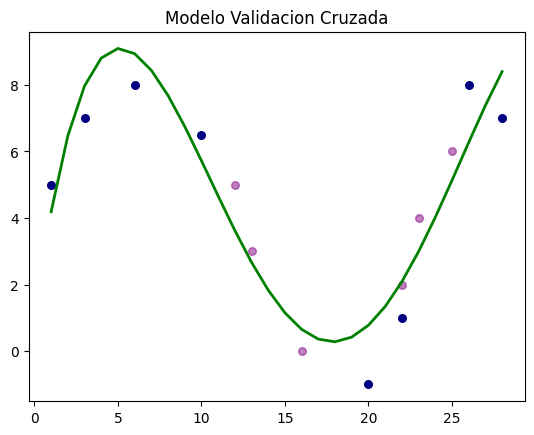

In [ ]:
X_plot = np.arange(x.min(),x.max()+1)
prediccion = mejor_modelo.predict(X_plot.reshape(-1,1))

plt.title("Modelo Validacion Cruzada")
plt.scatter(x_extra, y_extra, color='purple', s=30, marker='o',alpha=0.5)
plt.scatter(x, y, color='navy', s=30, marker='o')
plt.plot(X_plot, prediccion, color="green", linewidth=2)
plt.show()

# Ejercicio

Entrenar un modelo de regresión lineal y también utilice validación cruzada para entrenar un modelo de regresión polinomial variando el grado entre 1 y 5 con folds=4.

Utilizaremos un dataset que contiene datos sobre diferentes especies de peces y sus caracteristicas.


Columnas:
- Species: especie del pez (categórica)
- Weight: peso (en gramos) --> VARIABLE A PREDECIR
- Length1, Length2, Length3: distintas longitudes (en cm)
- Height: altura del cuerpo (en cm)
- Width: ancho del cuerpo (en cm)

Utilizar todas las columnas excepto Species para predecir el peso del pez (Weight)

In [ ]:
dataset = pd.read_csv("https://raw.githubusercontent.com/Ankit152/Fish-Market/refs/heads/main/Fish.csv")
dataset

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [ ]:
#Vamos a ocupar solo las variables numericas del dataset
dataset[["Length1", "Length2", "Length3", "Height", "Width"]]

,Length1,Length2,Length3,Height,Width
0,23.2,25.4,30.0,11.5200,4.0200
1,24.0,26.3,31.2,12.4800,4.3056
2,23.9,26.5,31.1,12.3778,4.6961
3,26.3,29.0,33.5,12.7300,4.4555
4,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...
154,11.5,12.2,13.4,2.0904,1.3936
155,11.7,12.4,13.5,2.4300,1.2690
156,12.1,13.0,13.8,2.2770,1.2558
157,13.2,14.3,15.2,2.8728,2.0672


In [ ]:
X = dataset[["Length1", "Length2", "Length3", "Height", "Width"]].values
y = dataset.Weight.values

#dividimos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=120)

In [ ]:
#Dejar todos los valores en el mismo rango
#En este ejercicio normalizamos porque la regresión polinomial genera potencias de las variables y estas pueden crecer mucho.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Regresión Lineal

In [ ]:
ols_reg = LinearRegression()
ols_reg.fit(X_train, y_train)
lin_pred = ols_reg.predict(X_test)
print("MSE Regresion lineal: %.3f" % mean_squared_error(y_test, lin_pred))
print("r2 Regresion lineal: %.3f" %  r2_score(y_test, lin_pred))

MSE Regresion lineal: 11749.988
r2 Regresion lineal: 0.910


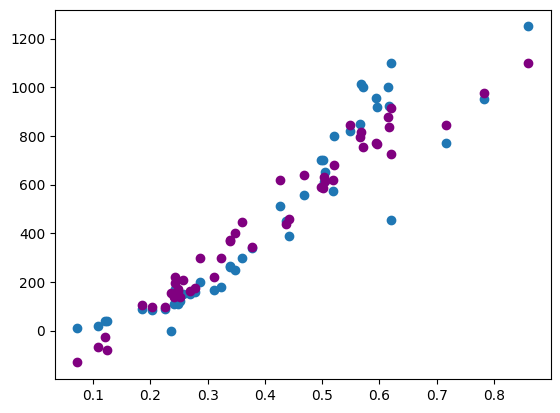

In [ ]:
plt.scatter(X_test[:,2], y_test)
plt.scatter(X_test[:,2], lin_pred, color="purple")
plt.show()

## Validacion cruzada


In [ ]:
from sklearn.model_selection import GridSearchCV
#Creamos nuestro modelo
modelo = PolynomialRegression()
#Creamos nuestra instancia de la validacion cruzada (es como un modelo)

parametros = {
    "grado": np.arange(1,6)
}

cv_model = GridSearchCV(modelo,
                        parametros,
                        cv=4, #Aqui se indica el numero de folds
                        scoring='neg_mean_squared_error',
                        verbose=3) #Le pasamos el modelo, los parametros, el indicador para ver cuando los datos son train o val y la métrica


In [ ]:
cv_model.fit(X_train, y_train)

Fitting 4 folds for each of 5 candidates, totalling 20 fits
[CV 1/4] END ......................grado=1;, score=-19777.572 total time=   0.0s
[CV 2/4] END .......................grado=1;, score=-9979.073 total time=   0.0s
[CV 3/4] END ......................grado=1;, score=-19844.574 total time=   0.0s
[CV 4/4] END ......................grado=1;, score=-33655.266 total time=   0.0s
[CV 1/4] END .......................grado=2;, score=-3869.061 total time=   0.0s
[CV 2/4] END .......................grado=2;, score=-2452.426 total time=   0.0s
[CV 3/4] END .......................grado=2;, score=-5525.091 total time=   0.0s
[CV 4/4] END .......................grado=2;, score=-7156.332 total time=   0.0s
[CV 1/4] END .......................grado=3;, score=-6181.509 total time=   0.0s
[CV 2/4] END .......................grado=3;, score=-7730.938 total time=   0.0s
[CV 3/4] END ......................grado=3;, score=-37339.504 total time=   0.0s
[CV 4/4] END ......................grado=3;, scor

GridSearchCV(cv=4, estimator=PolynomialRegression(),
             param_grid={'grado': array([1, 2, 3, 4, 5])},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
cv_model.best_params_

{'grado': np.int64(2)}

In [ ]:
mejor_modelo = cv_model.best_estimator_

In [ ]:
poly_pred = mejor_modelo.predict(X_test) #Predecimos

#Evaluamos
print("MSE Regresion lineal: %.3f" % mean_squared_error(y_test, poly_pred))
print("r2 Regresion lineal: %.3f" %  r2_score(y_test, poly_pred))

MSE Regresion lineal: 3910.470
r2 Regresion lineal: 0.970


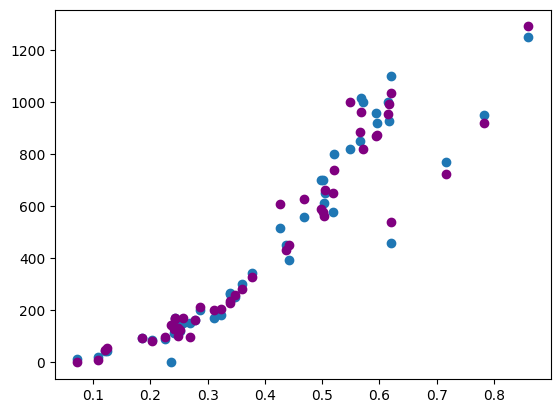

In [ ]:
plt.scatter(X_test[:,2], y_test)
plt.scatter(X_test[:,2], poly_pred, color="purple")
plt.show()

In [ ]:
if mean_squared_error(y_test, poly_pred) < mean_squared_error(y_test, lin_pred):
  print("Polinomial tienen un mejor MSE")
else:
  print("Lineal tiene un mejor MSE")
if r2_score(y_test, poly_pred) > r2_score(y_test, lin_pred):
  print("Polinomial tienen un mejor R2")
else:
  print("Lineal tiene un mejor R2")

Polinomial tienen un mejor MSE
Polinomial tienen un mejor R2
